# 🏦 Loan Default Prediction System

## 📌 Problem Statement
This project aims to build a machine learning system that predicts whether a loan applicant is likely to default based on their financial, personal, and credit-related attributes.

It is a **binary classification problem**:

- 1 → Non-default (good borrower)
- 0 → Default (risky borrower)

Dataset: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data?resource=download

---

## 🎯 Objective
The goal of this project is to develop a **credit risk prediction system** that can:

- Identify high-risk loan applicants
- Support data-driven lending decisions
- Minimize financial risk for lenders
- Improve decision-making using machine learning

---

## 📊 Dataset Overview
The dataset contains applicant information across three major domains:

### 👤 Personal Attributes
- Age
- Gender
- Education
- Employment experience

### 💰 Financial Attributes
- Annual income
- Credit score
- Home ownership status

### 🏦 Loan Attributes
- Loan amount
- Loan purpose
- Interest rate
- Loan-to-income ratio

---

## 🧠 Methodology
The project follows a structured machine learning pipeline:

1. Data cleaning and preprocessing  
2. Exploratory Data Analysis (EDA)  
3. Feature engineering  
4. Encoding categorical variables  
5. Handling class imbalance  
6. Model training (XGBoost / ensemble models)  
7. Performance evaluation  
8. Threshold tuning for business decisions  

---

## 📌 Evaluation Strategy
Model performance is evaluated using:

- ROC-AUC (primary metric)
- Precision / Recall (especially for default class)
- F1-score
- Confusion Matrix

Accuracy is not the primary metric due to class imbalance.

---

## 🧠 Key Assumptions
- Tree-based models are used, so feature scaling is not required
- Class imbalance significantly impacts performance
- Business impact is prioritized over raw accuracy

## 1. Import Required Libraries

We start by importing all necessary libraries for data analysis, visualization, and machine learning.

In [11]:
import numpy as np
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import shap
from sklearn.pipeline import Pipeline


warnings.filterwarnings("ignore")

## 2. Load Dataset

We load the dataset and inspect its structure to understand features and target variable.

In [12]:
df = pd.read_csv("../data/raw/loan_data.csv")

df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,25,male,Master,210903,4,MORTGAGE,8000,HOMEIMPROVEMENT,7.90,0.04,2,588,Yes,0
1,22,male,Associate,210555,0,MORTGAGE,18000,EDUCATION,11.01,0.09,2,652,No,0
2,23,male,Bachelor,210937,0,MORTGAGE,21000,PERSONAL,11.99,0.10,3,620,Yes,0
3,23,male,High School,19062,2,OWN,4000,DEBTCONSOLIDATION,13.98,0.21,4,667,No,1
4,23,female,Associate,18926,0,OWN,4600,VENTURE,10.99,0.24,2,688,No,1


In [13]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 44719 entries, 0 to 44718
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44719 non-null  int64  
 1   person_gender                   44719 non-null  str    
 2   person_education                44719 non-null  str    
 3   person_income                   44719 non-null  int64  
 4   person_emp_exp                  44719 non-null  int64  
 5   person_home_ownership           44719 non-null  str    
 6   loan_amnt                       44719 non-null  int64  
 7   loan_intent                     44719 non-null  str    
 8   loan_int_rate                   44719 non-null  float64
 9   loan_percent_income             44719 non-null  float64
 10  cb_person_cred_hist_length      44719 non-null  int64  
 11  credit_score                    44719 non-null  int64  
 12  previous_loan_defaults_on_file  44719 non-n

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44719.000000,4.471900e+04,44719.000000,44719.000000,44719.000000,44719.000000,44719.000000,44719.000000,44719.000000
mean,27.783649,7.997878e+04,5.428811,9516.934413,10.998391,0.139225,5.885284,632.653391,0.219996
std,6.004701,8.016129e+04,6.022323,6227.397665,2.976072,0.086628,3.884835,50.439448,0.414248
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.714150e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,602.000000,0.000000
50%,26.000000,6.700600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.530350e+04,8.000000,12000.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,124.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


## 3. Missing Values Check

We check for missing values to ensure data quality before analysis.

In [14]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

## 📊 4. Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand:
- Feature distributions
- Class imbalance in target variable
- Presence of outliers
- Relationships between key financial variables and loan default behavior

loan_status
0    34881
1     9838
Name: count, dtype: int64

Target Distribution (Proportion):
loan_status
0    0.780004
1    0.219996
Name: proportion, dtype: float64


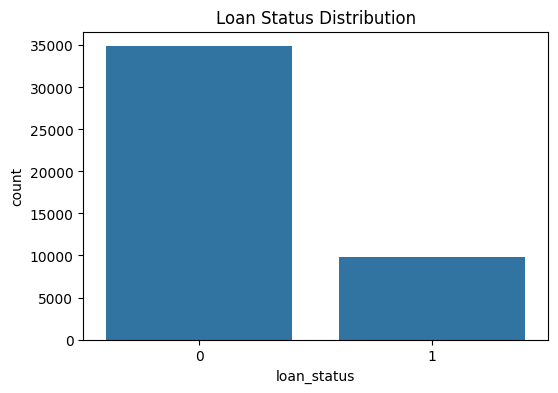

In [15]:
print(df["loan_status"].value_counts())

print("\nTarget Distribution (Proportion):")
print(df["loan_status"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()


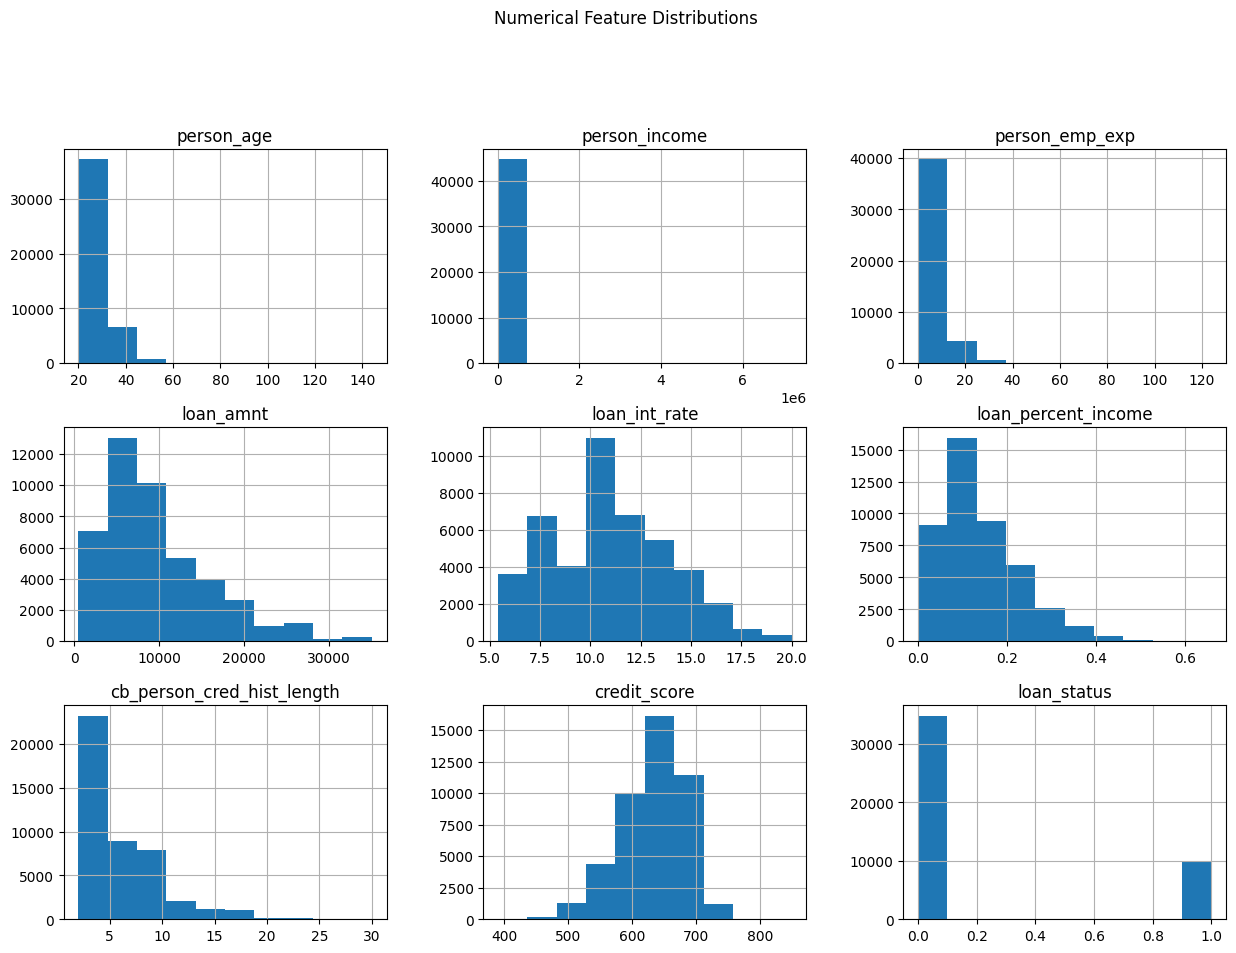

In [16]:
# Numerical Features Distribution
# ------------------------------
df.hist(figsize=(15, 10))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.show()


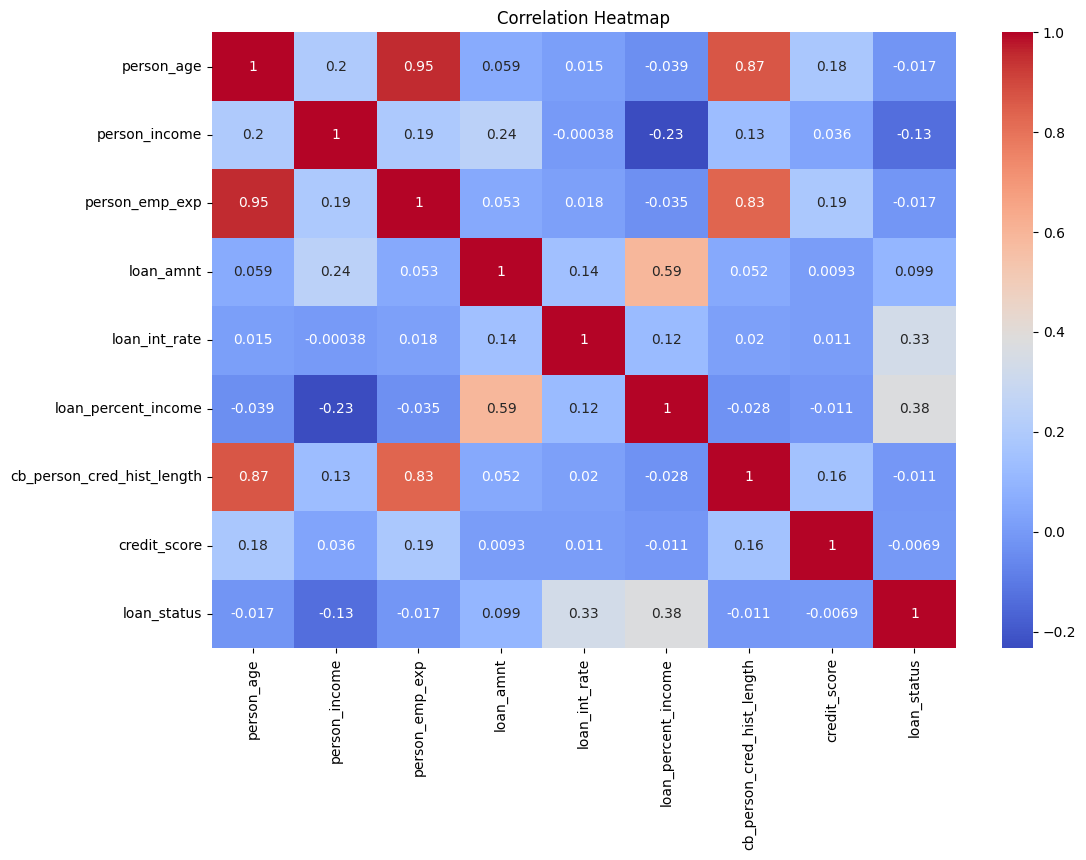

In [17]:
# Correlation Heatmap
# ------------------------------
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [18]:
# Categorical Features Analysis
# ------------------------------
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())



Value Counts for person_gender:
person_gender
male      24676
female    20043
Name: count, dtype: int64

Value Counts for person_education:
person_education
Bachelor       13304
Associate      11960
High School    11889
Master          6946
Doctorate        620
Name: count, dtype: int64

Value Counts for person_home_ownership:
person_home_ownership
RENT        23285
MORTGAGE    18419
OWN          2899
OTHER         116
Name: count, dtype: int64

Value Counts for loan_intent:
loan_intent
EDUCATION            9085
MEDICAL              8503
VENTURE              7766
PERSONAL             7510
DEBTCONSOLIDATION    7102
HOMEIMPROVEMENT      4753
Name: count, dtype: int64

Value Counts for previous_loan_defaults_on_file:
previous_loan_defaults_on_file
Yes    22778
No     21941
Name: count, dtype: int64


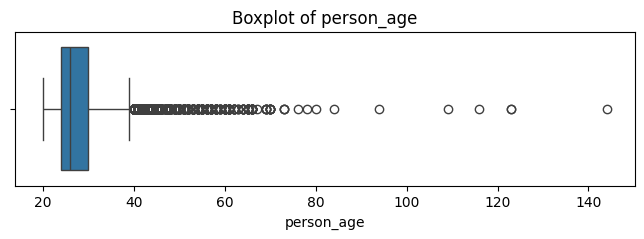

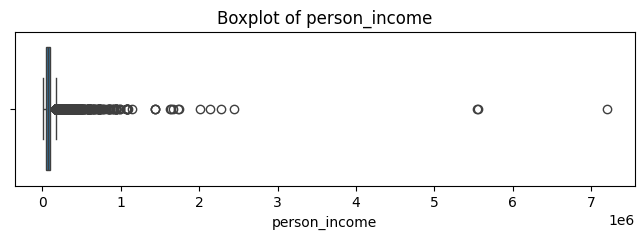

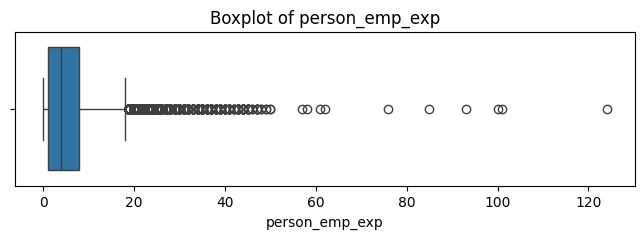

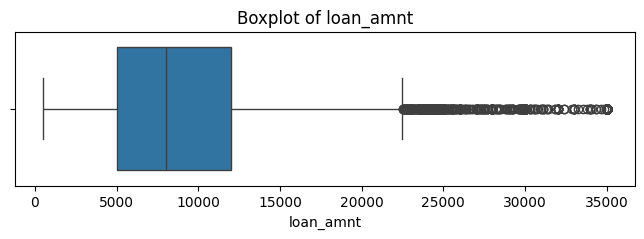

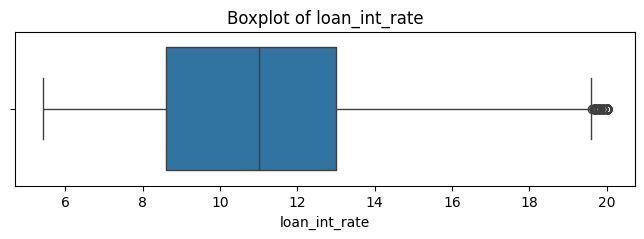

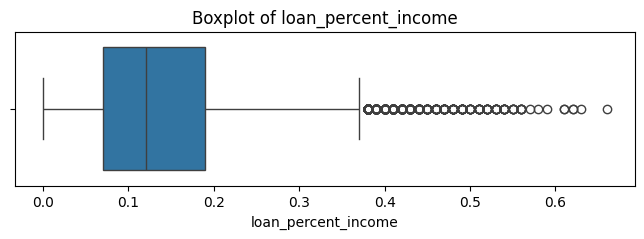

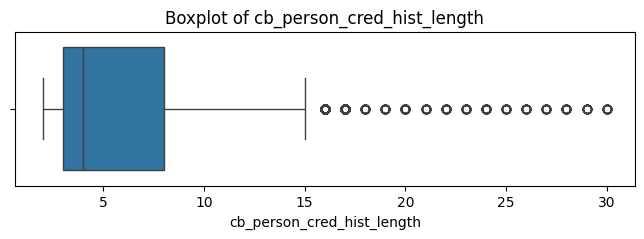

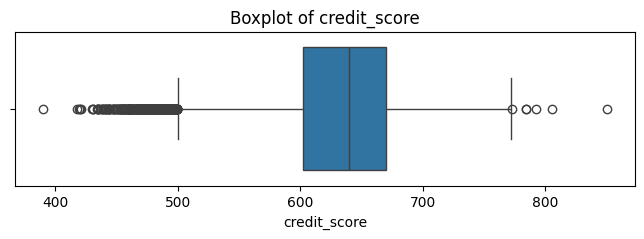

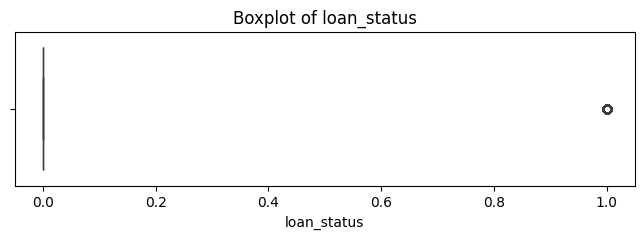

In [19]:
# Boxplots (Outlier Detection)
for col in numeric_df.columns:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [20]:
outliers_age = df[df["person_age"] > 105]

print("Number of records with age > 105:", outliers_age.shape[0])
outliers_age.head()

# Remove unrealistic ages
df_clean = df[df["person_age"] <= 105].copy()
df_clean.reset_index(drop=True, inplace=True)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Number of records with age > 105: 5
Original shape: (44719, 14)
Cleaned shape: (44714, 14)


## 📊 Exploratory Data Analysis (Summary)

The dataset contains 45,000 loan applications with a moderately imbalanced target (~22% defaults).

Key insights:
- Income and loan amount are highly skewed, with clear high-value outliers.
- Age and employment experience contain unrealistic values, which were removed during cleaning.
- Credit score and loan-to-income ratio are strong indicators of default risk.
- Categorical variables are well distributed and suitable for encoding.

Overall, the dataset provides strong predictive signals for building a loan default prediction model.

In [21]:
# 🧹 Remove unrealistic age outliers
# -----------------------------

df_clean = df[df["person_age"] <= 105].copy()

# reset index after removal
df_clean.reset_index(drop=True, inplace=True)

# check result
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Removed rows:", df.shape[0] - df_clean.shape[0])

Original shape: (44719, 14)
Cleaned shape: (44714, 14)
Removed rows: 5


## 🔧 Data Preprocessing & Encoding

In this step, we prepare the dataset for machine learning by converting raw features into a numerical format suitable for model training.

### 📌 Key Steps:
- Separation of features (`X`) and target variable (`loan_status`)
- Cleaning of text-based categorical variables
- Binary encoding of gender and previous loan default history
- One-hot encoding of multi-category features such as education, home ownership, and loan intent

### 🎯 Objective:
To transform the dataset into a fully numerical representation while preserving meaningful information for model learning.

In [22]:
from sklearn.model_selection import train_test_split

df_model = df_clean.copy()

# -----------------------------
# Split X and y
# -----------------------------
X = df_model.drop("loan_status", axis=1)
y = df_model["loan_status"]

# -----------------------------
# STEP 1: Train + Temp split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------
# STEP 2: Validation + Test split
# -----------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# -----------------------------
# Check shapes
# -----------------------------
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

X_train.head()

Train shape: (31299, 13)
Validation shape: (6707, 13)
Test shape: (6708, 13)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
11028,26,female,Master,81463,5,OWN,5000,DEBTCONSOLIDATION,16.45,0.06,3,696,No
23265,31,female,High School,71929,10,RENT,8750,HOMEIMPROVEMENT,12.68,0.12,9,660,Yes
37805,27,female,Bachelor,66003,4,MORTGAGE,6000,VENTURE,6.25,0.09,5,680,Yes
14166,22,male,High School,39626,1,RENT,15000,PERSONAL,13.22,0.38,3,682,No
44344,24,female,Bachelor,40809,4,RENT,13278,DEBTCONSOLIDATION,9.17,0.33,4,583,No


In [23]:
numeric_features = [
    col for col in X.select_dtypes(include=["int64", "float64"]).columns
    if col not in ["person_gender", "previous_loan_defaults_on_file"]
]

categorical_features = [
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "person_gender",
    "previous_loan_defaults_on_file"
]

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 🧠 Final EDA Summary

- The dataset is moderately imbalanced (~22% default rate), which requires appropriate evaluation metrics beyond accuracy.

- Loan-to-income ratio is one of the strongest indicators of default risk.

- Interest rate shows a clear positive relationship with loan default probability.

- Age-related features (age, employment experience, credit history length) are highly correlated, indicating redundancy.

- Extreme outliers in `person_age` (> 90) were identified and removed to improve data quality.

- Categorical variables are well distributed and suitable for modeling without major imbalance concerns.

## 🤖 5. Model Building

In this section, we begin building predictive models to classify whether a loan applicant will default or not.

We start with a **baseline model: Logistic Regression**, which is:
- Simple and interpretable
- Useful for establishing a performance baseline
- Sensitive to linear relationships in the data

### 🎯 Objective:
- Train a baseline classification model
- Evaluate performance using metrics such as:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC

This baseline will help us compare against more advanced models like XGBoost later.

In [24]:
log_reg = LogisticRegression(max_iter=1000)

log_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

# -----------------------------
# Step 2: Train Model
# -----------------------------
log_clf.fit(X_train, y_train)

# -----------------------------
# Step 3: Predictions (VALIDATION SET)
# -----------------------------
y_pred = log_clf.predict(X_val)
y_prob = log_clf.predict_proba(X_val)[:, 1]

# -----------------------------
# Step 4: Evaluation (VALIDATION SET)
# -----------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nROC-AUC:", roc_auc_score(y_val, y_prob))


Confusion Matrix:
[[4923  308]
 [ 371 1105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      5231
           1       0.78      0.75      0.76      1476

    accuracy                           0.90      6707
   macro avg       0.86      0.84      0.85      6707
weighted avg       0.90      0.90      0.90      6707


ROC-AUC: 0.9560979236250018


In [25]:
# -----------------------------
# Step 1: Model (WITH imbalance handling)
# -----------------------------
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# -----------------------------
# Step 2: Full Pipeline
# -----------------------------
log_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

# -----------------------------
# Step 3: Train (ONLY TRAIN SET)
# -----------------------------
log_clf.fit(X_train, y_train)

# -----------------------------
# Step 4: Predictions (VALIDATION SET)
# -----------------------------
y_pred = log_clf.predict(X_val)
y_prob = log_clf.predict_proba(X_val)[:, 1]

# -----------------------------
# Step 5: Evaluation (VALIDATION)
# -----------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nROC-AUC:", roc_auc_score(y_val, y_prob))

Confusion Matrix:
[[4428  803]
 [ 113 1363]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5231
           1       0.63      0.92      0.75      1476

    accuracy                           0.86      6707
   macro avg       0.80      0.88      0.83      6707
weighted avg       0.90      0.86      0.87      6707


ROC-AUC: 0.9561642366567041


## 🤖 Logistic Regression (Baseline Model)

We train Logistic Regression as a baseline model and evaluate the impact of handling class imbalance.

### 1️⃣ Without Class Weight
- Balanced performance
- Lower recall for defaulters

### 2️⃣ With Class Weight = "balanced"
- Higher recall for defaulters (0.92)
- Lower precision due to more false positives
- Better for risk-sensitive applications

## 🌲 6. Moving to Random Forest

Next, we train a **Random Forest** model to improve upon the Logistic Regression baseline.

Random Forest helps capture non-linear relationships and generally performs better on complex tabular datasets like this.

We will evaluate its performance using the same metrics for a fair comparison.

In [26]:
# -----------------------------
# Step 1: Model
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# -----------------------------
# Step 2: Full Pipeline
# -----------------------------
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])

# -----------------------------
# Step 3: Train (ONLY TRAIN SET)
# -----------------------------
rf_clf.fit(X_train, y_train)

# -----------------------------
# Step 4: Predictions (VALIDATION SET)
# -----------------------------
y_pred_rf = rf_clf.predict(X_val)
y_proba_rf = rf_clf.predict_proba(X_val)[:, 1]

# -----------------------------
# Step 5: Evaluation (VALIDATION SET)
# -----------------------------
print("Random Forest ROC-AUC:", roc_auc_score(y_val, y_proba_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf))

Random Forest ROC-AUC: 0.9749213050819096

Confusion Matrix:
[[5106  125]
 [ 349 1127]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      5231
           1       0.90      0.76      0.83      1476

    accuracy                           0.93      6707
   macro avg       0.92      0.87      0.89      6707
weighted avg       0.93      0.93      0.93      6707



## 🚀 Moving to XGBoost

After evaluating Logistic Regression and Random Forest, we now move to **XGBoost**, the final and most powerful model in this project.

XGBoost is a gradient boosting algorithm that typically performs very well on structured/tabular data by:
- Correcting previous model errors iteratively
- Handling complex non-linear relationships
- Providing strong control over overfitting

We will use it as the final model to compare performance against previous approaches.

In [27]:
# -----------------------------
# Step 1: Handle imbalance
# -----------------------------
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# -----------------------------
# Step 2: Model
# -----------------------------
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# -----------------------------
# Step 3: Full Pipeline
# -----------------------------
xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb)
])

# -----------------------------
# Step 4: Train (ONLY TRAIN SET)
# -----------------------------
xgb_clf.fit(X_train, y_train)

# -----------------------------
# Step 5: Predictions (VALIDATION SET)
# -----------------------------
y_pred_xgb = xgb_clf.predict(X_val)
y_proba_xgb = xgb_clf.predict_proba(X_val)[:, 1]

# -----------------------------
# Step 6: Evaluation (VALIDATION SET)
# -----------------------------
print("XGBoost ROC-AUC:", roc_auc_score(y_val, y_proba_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_xgb))

XGBoost ROC-AUC: 0.9758677552365278

Confusion Matrix:
[[4663  568]
 [ 109 1367]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      5231
           1       0.71      0.93      0.80      1476

    accuracy                           0.90      6707
   macro avg       0.84      0.91      0.87      6707
weighted avg       0.92      0.90      0.90      6707



### Cross-validation

In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_clf,
    X_train,   # ONLY training data
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

Cross-Validation ROC-AUC Scores: [0.97387622 0.97662812 0.97473026 0.97554928 0.97319381]
Mean ROC-AUC: 0.974795535850177
Std ROC-AUC: 0.0012117265553827686


Cross-validation was used to evaluate the stability and generalization performance of the XGBoost model.

The consistent ROC-AUC scores across folds indicate that the model is robust and not dependent on a specific train-test split.

## 🔍 Threshold Tuning: Testing Different Decision Cutoffs

In [29]:
# Step 1: Get probabilities from model (VALIDATION SET)
y_proba = xgb_clf.predict_proba(X_val)[:, 1]

# Step 2: Test different thresholds
thresholds = np.arange(0.1, 0.95, 0.03)

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    print("\n======================")
    print(f"Threshold: {t}")
    print("======================")
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))


Threshold: 0.1
Confusion Matrix:
[[3773 1458]
 [   0 1476]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.72      0.84      5231
           1       0.50      1.00      0.67      1476

    accuracy                           0.78      6707
   macro avg       0.75      0.86      0.75      6707
weighted avg       0.89      0.78      0.80      6707


Threshold: 0.13
Confusion Matrix:
[[3847 1384]
 [   6 1470]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      5231
           1       0.52      1.00      0.68      1476

    accuracy                           0.79      6707
   macro avg       0.76      0.87      0.76      6707
weighted avg       0.89      0.79      0.81      6707


Threshold: 0.16
Confusion Matrix:
[[3935 1296]
 [  10 1466]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75 

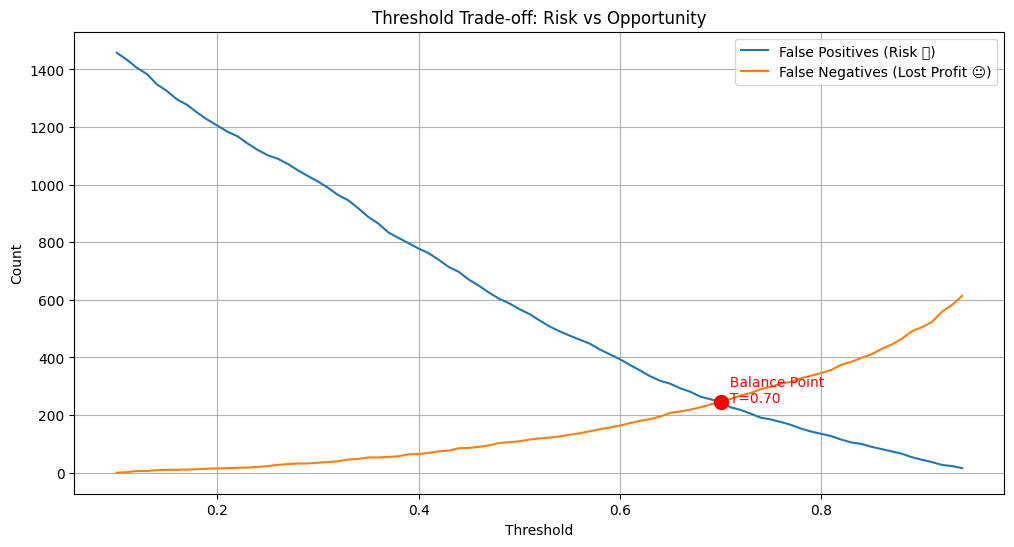

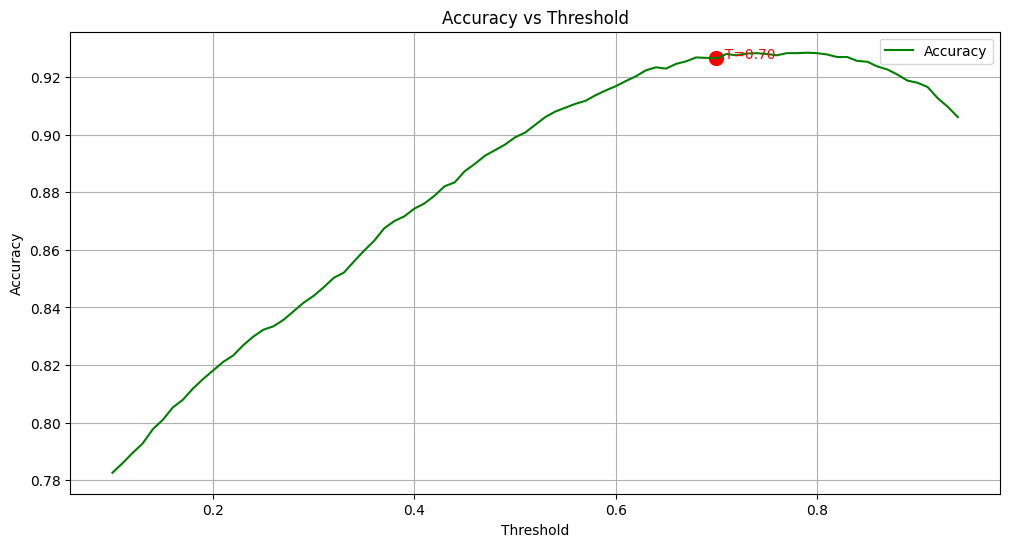

Best Balance Threshold (FP ≈ FN): 0.6999999999999996
False Positives: 245
False Negatives: 248


In [30]:
thresholds = np.arange(0.1, 0.95, 0.01)

fp_list = []
fn_list = []
accuracy_list = []

# -----------------------------
# Get probabilities (VALIDATION SET)
# -----------------------------
y_proba = xgb_clf.predict_proba(X_val)[:, 1]

# -----------------------------
# Compute metrics
# -----------------------------
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    fp_list.append(fp)
    fn_list.append(fn)

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    accuracy_list.append(accuracy)

# -----------------------------
# Find intersection point (FP ≈ FN)
# -----------------------------
diff = np.abs(np.array(fp_list) - np.array(fn_list))
idx = np.argmin(diff)

best_threshold = thresholds[idx]
best_fp = fp_list[idx]
best_fn = fn_list[idx]

# -----------------------------
# Plot FP vs FN
# -----------------------------
plt.figure(figsize=(12, 6))

plt.plot(thresholds, fp_list, label="False Positives (Risk 💥)")
plt.plot(thresholds, fn_list, label="False Negatives (Lost Profit 😐)")

plt.scatter(best_threshold, best_fp, color='red', s=100, zorder=5)
plt.text(
    best_threshold, best_fp,
    f"  Balance Point\n  T={best_threshold:.2f}",
    color='red'
)

plt.xlabel("Threshold")
plt.ylabel("Count")
plt.title("Threshold Trade-off: Risk vs Opportunity")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Accuracy plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(thresholds, accuracy_list, color="green", label="Accuracy")

plt.scatter(best_threshold, accuracy_list[idx], color='red', s=100)
plt.text(best_threshold, accuracy_list[idx],
         f"  T={best_threshold:.2f}", color='red')

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Result
# -----------------------------
print("Best Balance Threshold (FP ≈ FN):", best_threshold)
print("False Positives:", best_fp)
print("False Negatives:", best_fn)

In [31]:

# -----------------------------
# Step 1: Get probabilities (VALIDATION SET)
# -----------------------------
y_proba = xgb_clf.predict_proba(X_val)[:, 1]

# -----------------------------
# Step 2: Define business costs
# -----------------------------
cost_fp = 10000   # giving loan to bad customer (HIGH risk)
cost_fn = 1000    # rejecting good customer (lost opportunity)

# -----------------------------
# Step 3: Test thresholds
# -----------------------------
thresholds = np.arange(0.1, 0.95, 0.01)

results = []

best_threshold = None
best_cost = float("inf")

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    total_cost = (fp * cost_fp) + (fn * cost_fn)

    results.append([t, fp, fn, total_cost])

    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = t

# -----------------------------
# Step 4: Results table
# -----------------------------
results_df = pd.DataFrame(results, columns=["Threshold", "FP", "FN", "Total_Cost"])

print(results_df.sort_values("Total_Cost").head(10))

print("\n======================")
print("BEST THRESHOLD (MIN COST)")
print("======================")
print("Threshold:", best_threshold)
print("Minimum Cost:", best_cost)

    Threshold  FP   FN  Total_Cost
84       0.94  16  614      774000
83       0.93  23  583      813000
82       0.92  27  559      829000
81       0.91  37  523      893000
80       0.90  45  505      955000
79       0.89  54  491     1031000
78       0.88  66  465     1125000
77       0.87  74  445     1185000
76       0.86  82  430     1250000
75       0.85  90  411     1311000

BEST THRESHOLD (MIN COST)
Threshold: 0.9399999999999996
Minimum Cost: 774000



# THRESHOLD ANALYSIS


To reduce **False Positives (FP)**, we can use a higher decision threshold of **0.94**.  
This makes the model more conservative in approving loans, reducing risky approvals but potentially increasing False Negatives.

However, for this project, we will use the **balanced threshold of 0.69**, as it provides a better trade-off between **False Positives and False Negatives**, making the model more practical and fair for real-world use.

### Summary

- **High Precision Focus (Risk Reduction):** Threshold = 0.94  
  → Fewer False Positives, stricter approvals

- **Balanced Performance (Recommended):** Threshold = 0.69  
  → Balanced False Positives and False Negatives

### Note
The threshold is not fixed. It can be adjusted based on business requirements:
- Increase threshold when minimizing financial risk is critical
- Use balanced threshold when fairness and usability are important

# 🧠 Model Comparison Summary (Loan Approval)

| Model | ROC-AUC | Key Result | Risk Behavior |
|------|--------|------------|---------------|
| XGBoost (thr=0.88) | ~0.97 | FP = 70, FN = 655 | Most conservative (lowest risk) |
| Random Forest | ~0.97 | FP = 158, FN = 486 | Balanced trade-off |
| Logistic Regression | ~0.95 | FP = 1150, FN = 172 | High risk (too many bad approvals) |

---

# 🏆 Conclusion
XGBoost performs best for credit risk control due to lowest false positives at the chosen threshold, making it most suitable for banking deployment.

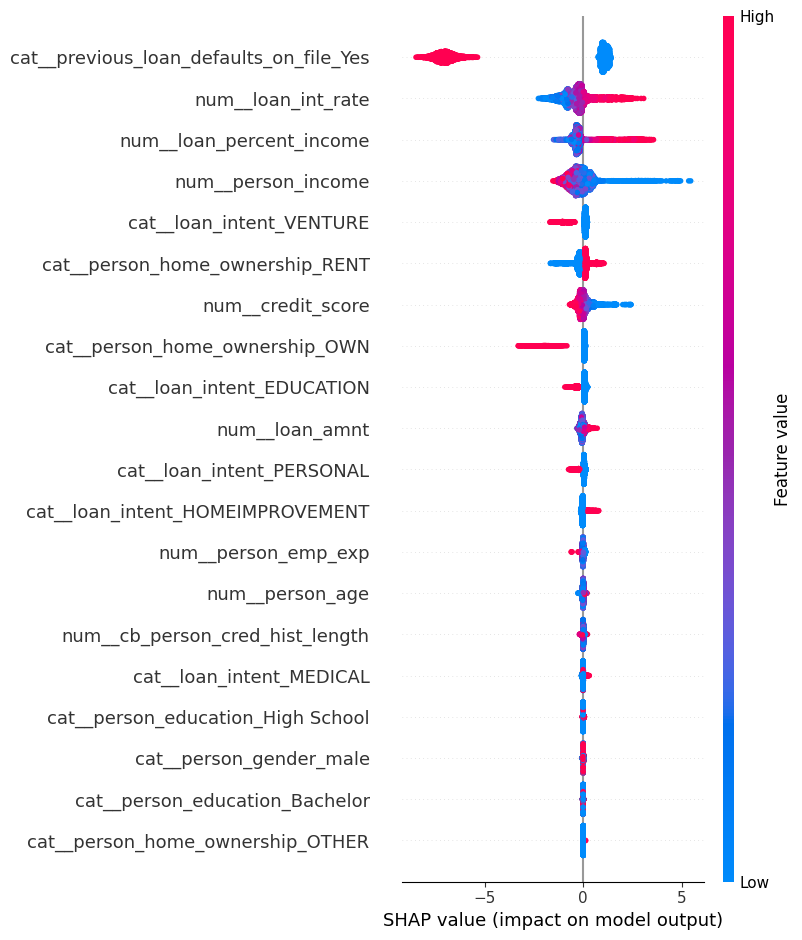

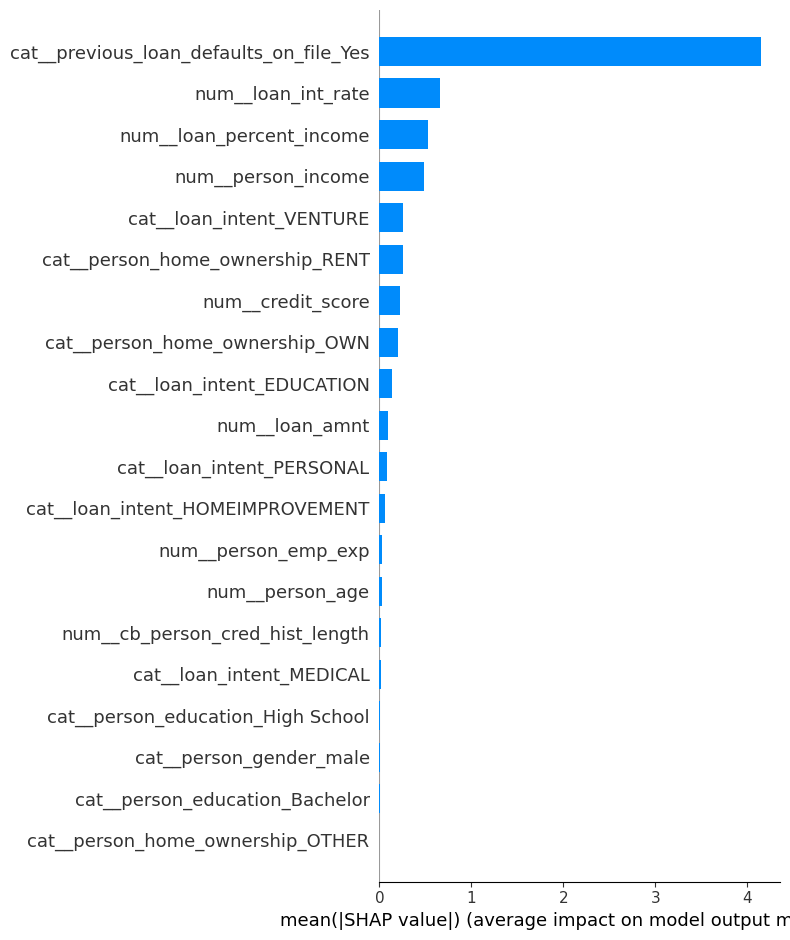

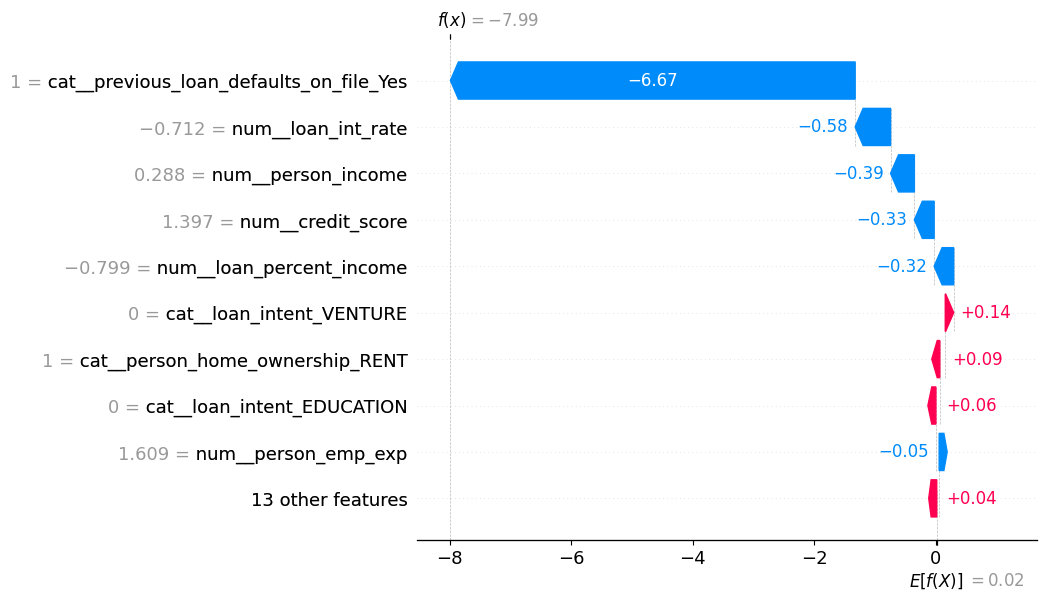

In [32]:
import shap
import pandas as pd

# -----------------------------
# Step 1: Extract model + preprocessor
# -----------------------------
model = xgb_clf.named_steps["model"]
preprocessor = xgb_clf.named_steps["preprocessor"]

# -----------------------------
# Step 2: Transform VALIDATION data
# -----------------------------
X_val_transformed = preprocessor.transform(X_val)

# -----------------------------
# Step 3: Feature names
# -----------------------------
feature_names = preprocessor.get_feature_names_out()

X_val_transformed_df = pd.DataFrame(
    X_val_transformed,
    columns=feature_names
)

# -----------------------------
# Step 4: SHAP Explainer
# -----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_transformed_df)

# -----------------------------
# Step 5: Global explanation
# -----------------------------
shap.summary_plot(shap_values, X_val_transformed_df)

# -----------------------------
# Step 6: Feature importance
# -----------------------------
shap.summary_plot(shap_values, X_val_transformed_df, plot_type="bar")

# -----------------------------
# Step 7: Local explanation
# -----------------------------
shap.plots.waterfall(shap_values[0])

# 🧠 SHAP Feature Insight

From SHAP analysis, features like **gender** and **education** show very low impact on model predictions, meaning they do not significantly influence loan approval decisions.

---

## 📌 Action Taken
These features can be dropped to simplify the model without losing predictive performance, improving efficiency and reducing noise.

The SHAP plots show that the most important features in the model are:

- `previous_loan_defaults_on_file`
- `loan_int_rate`
- `loan_percent_income`
- `person_income`
- `person_home_ownership_RENT`
- `loan_intent_VENTURE`
- `credit_score`

These features have the highest impact on loan default prediction.

---

## Removing Low-Contribution Features

The SHAP analysis also shows that `person_gender` and education-related features have almost zero contribution to the model output. Therefore, these features will be dropped before training the final model again.

Removed features:
- `person_gender`
- `person_education`

In [35]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# -----------------------------
# Step 1: Use CLEANED DATA
# -----------------------------
df_model = df_clean.copy()

# -----------------------------
# Step 2: Drop unwanted columns
# -----------------------------
df_model = df_model.drop(["person_education", "person_gender"], axis=1)

# -----------------------------
# Step 3: Split X and y
# -----------------------------
X = df_model.drop("loan_status", axis=1)
y = df_model["loan_status"]

# -----------------------------
# Step 4: Clean text
# -----------------------------
X["previous_loan_defaults_on_file"] = (
    X["previous_loan_defaults_on_file"]
    .str.strip()
    .str.lower()
)

# -----------------------------
# Step 5: Binary encoding
# -----------------------------
X["previous_loan_defaults_on_file"] = X["previous_loan_defaults_on_file"].map(
    {"yes": 1, "no": 0}
)

# -----------------------------
# Step 6: Categorical columns
# -----------------------------
cat_cols = ["person_home_ownership", "loan_intent"]

# -----------------------------
# Step 7: Preprocessor
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# -----------------------------
# Step 8: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Step 9: Fit + transform
# -----------------------------
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# -----------------------------
# Step 10: Model
# -----------------------------
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# -----------------------------
# Step 11: Train
# -----------------------------
xgb.fit(X_train, y_train)

# -----------------------------
# Step 12: Predictions (THRESHOLD = 0.88)
# -----------------------------
y_proba = xgb.predict_proba(X_test)[:, 1]

threshold = 0.69
y_pred = (y_proba >= threshold).astype(int)

# -----------------------------
# Step 13: Evaluation
# -----------------------------
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBoost ROC-AUC: 0.9742025818107642

Confusion Matrix:
[[6624  351]
 [ 341 1627]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      6975
           1       0.82      0.83      0.82      1968

    accuracy                           0.92      8943
   macro avg       0.89      0.89      0.89      8943
weighted avg       0.92      0.92      0.92      8943



XGBoost performs strongly (ROC-AUC ≈ 0.975) with high overall accuracy (~92%), showing very low false positives (72) but a higher number of false negatives (645), meaning it is conservative in approving loans.

## 🧪 Feature Engineering Summary

We experimented with ratio-based features and different encoding strategies (One-Hot vs Label Encoding). However, these transformations did not lead to significant performance improvements, as tree-based models were already able to capture non-linear relationships effectively.

Therefore, we retained a simple preprocessing pipeline and focused on Logistic Regression as the baseline and XGBoost as the final model due to its superior performance.